SalePrice       int64
LotArea         int64
OverallQual     int64
YearBuilt       int64
TotRmsAbvGrd    int64
GrLivArea       int64
GarageCars      int64
dtype: object


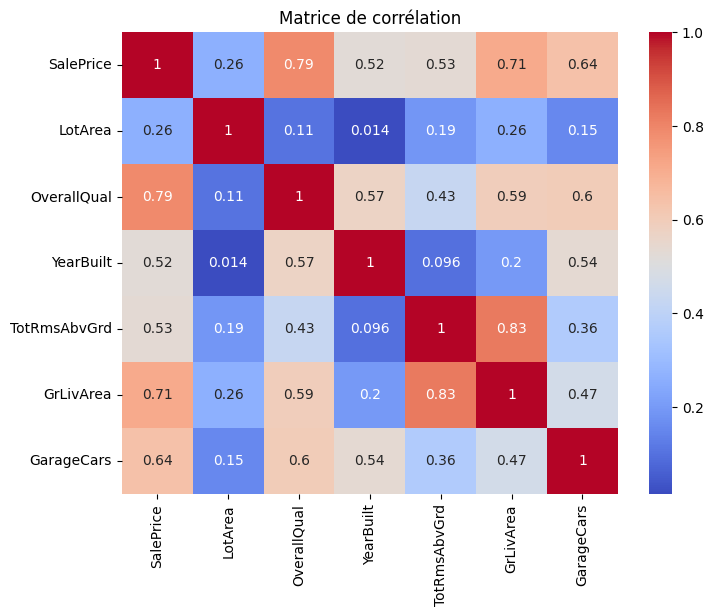


🔹 Linear Regression
RMSE : 41829.85021818346
R² : 0.7718824047357786

🔸 Random Forest
RMSE : 31032.74211199078
R² : 0.8744471803445645


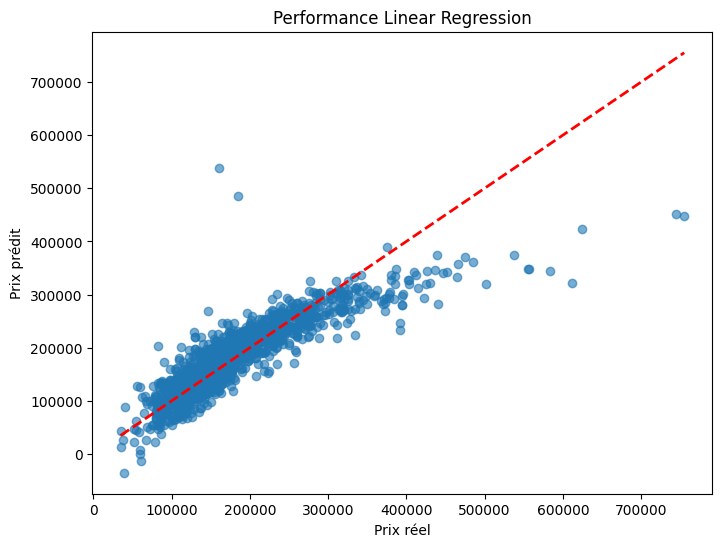

In [7]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Chemin
os.chdir("/home/massilia/Documents/PriceVision")

# =========================
# 1. Chargement du dataset
# =========================
df = pd.read_csv("Data/house_prices_kaggle.csv")

# Colonnes NUMÉRIQUES uniquement
cols = [
    "SalePrice",
    "LotArea",
    "OverallQual",
    "YearBuilt",
    "TotRmsAbvGrd",
    "GrLivArea",
    "GarageCars"
]

df = df[cols].dropna()

# Vérification
print(df.dtypes)

# =========================
# 2. Heatmap corrélation
# =========================
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

# =========================
# 3. Split
# =========================
X = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 4. Linear Regression
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

y_pred_lr = model.predict(X_test)

print("\n🔹 Linear Regression")
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R² :", r2_score(y_test, y_pred_lr))

joblib.dump(model, "model.pkl")

# =========================
# 5. Random Forest
# =========================
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n🔸 Random Forest")
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R² :", r2_score(y_test, y_pred_rf))

# =========================
# 6. Graph réel vs prédit
# =========================
y_true = y.values
y_pred = model.predict(X)

plt.figure(figsize=(8,6))
plt.scatter(y_true, y_pred, alpha=0.6)
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         'r--', linewidth=2)
plt.xlabel("Prix réel")
plt.ylabel("Prix prédit")
plt.title("Performance Linear Regression")
plt.show()
